# V4-4-0 Portfolio

อัปเดตจาก `V3-4_portfolio` ให้ตรงกับ pipeline ใหม่ (`v4-3-0_inferencing`):
- **Data source**: รับ arrays จาก inferencing loop โดยตรง (`all_prices_gen`, `all_prices_real`, `all_log_ret_gen`, `all_log_ret_real`, `all_dates`) แทน `SimulationDataset` / `.npz`
- **Tensor dims**: shape ใหม่ `(N, W, A, C)` แทน `(N, A, W, D, C)` — A และ W สลับกัน, ไม่มี D
- **No GBM**: ไม่มี `simulate_mc_gbm` เป็น benchmark อีกแล้ว — มีแค่ `"model"` strategy เดียว
- **Imports**: ใช้ `load_data` / `build_datasets` (utils/io.py) แทน `load_variant`

# 1. Import & Config

In [35]:
import sys, os, json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import quantstats as qs
from pathlib import Path

from config import InferenceConfig, DDPMTransformerConfig, FMConfig
from utils import setup_logging, setup_random_seed, load_data, build_datasets
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR
from entities import Portfolio

logger = setup_logging()
logger.info("✓ Imports OK")

2026-07-25 15:04:42,263 - utils.setup - INFO - Logger is set up.
2026-07-25 15:04:42,265 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config

In [36]:
# 1. Import & Config
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import InferenceConfig
from utils import setup_logging, setup_random_seed

logger = setup_logging()
logger.info("✓ Imports OK")

# ── 1.1 Config ────────────────────────────────────────────────────────
cfg = InferenceConfig(
    name             = "portfolio_config",
    group            = "set_index",
    subgroup         = "set_idx50",
    experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    checkpoint_file  = "best_model.pt",
    num_simulations  = 1000,
    random_seed      = 72,
)
cfg = cfg.apply_experiment_config()

SPLIT = "test" # เปลี่ยนเป็น 'test' ได้ตามที่เซฟมา
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"

setup_random_seed(cfg.random_seed)

print("=" * 60)
print("  V4-4-0 PORTFOLIO")
print("=" * 60)
print(f"  Experiment      : {cfg.experiment_name}")
print(f"  Simulation dir  : {sim_dir}")
print("=" * 60)

2026-07-25 15:04:42,645 - utils.setup - INFO - Logger is set up.
2026-07-25 15:04:42,646 - utils.setup - INFO - ✓ Imports OK
[InferenceConfig] model_params loaded from best_params.json
  V4-4-0 PORTFOLIO
  Experiment      : v1_trial01_w20a33_ddpm_warmup-cosine_optuna
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/set_index/set_idx50/v1_trial01_w20a33_ddpm_warmup-cosine_optuna/simulations/test_all_n1000


# 3. Portfolio Optimization Loop

In [37]:
# 2. Load Simulation Data (Direct Array Load)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"Not found: {npz_path} (รัน inferencing หรือยัง?)")

data = np.load(npz_path, allow_pickle=True)

# โหลด arrays (T = จำนวน window, N = sims, W = window_size, A = assets, C = channels)
all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  all_prices_gen   : {all_prices_gen.shape}")
print(f"  all_prices_real  : {all_prices_real.shape}")
print(f"  all_log_ret_gen  : {all_log_ret_gen.shape}")
print(f"  all_log_ret_real : {all_log_ret_real.shape}")
print(f"  all_dates        : {all_dates.shape}")
print(f"  tickers          : {len(tickers)} assets")

  ✓ Loaded 1 file from test_all_n1000
  all_prices_gen   : (41, 1000, 20, 33)
  all_prices_real  : (41, 20, 33)
  all_log_ret_gen  : (41, 1000, 20, 33, 4)
  all_log_ret_real : (41, 20, 33, 4)
  all_dates        : (41,)
  tickers          : 33 assets


In [38]:
# 2.2 Prepare GT & MC Returns/Prices
# แปลง (T, N, W, A) -> (N, T*W, A) สำหรับ MC
# แปลง (T, W, A) -> (T*W, A) สำหรับ GT

CLOSE_IDX = 0  # เปลี่ยนให้ตรงกับ features_lr ของคุณ (0 = Close ปกติใน v4)

# ── 1. Ground Truth (GT) ──────────────────────────────────────────────
# log_ret_real : (T, W, A, C) -> เอาแค่ channel Close
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # (T*W, A)

# prices_real : (T, W, A) ไม่มี C แล้ว
gt_prices = all_prices_real.reshape(-1, A)    # (T*W, A)

# dates : (T, W) -> flatten เป็น 1D (T*W)
if all_dates.ndim == 2:
    gt_dates = all_dates.flatten()
else:
    gt_dates = all_dates

# ── 2. Monte Carlo (MC) ───────────────────────────────────────────────
# log_ret_gen : (T, N, W, A, C) -> เอาแค่ channel Close
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N มาข้างหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # ยุบรวมแกนเวลา -> (N, T*W, A)

# prices_gen : (T, N, W, A)
mc_prices = all_prices_gen.transpose(1, 0, 2, 3) # (N, T, W, A)
mc_prices = mc_prices.reshape(N, -1, A)          # (N, T*W, A)

print("── Shapes after preparation ───────────────────────")
print(f"  gt_returns  : {gt_returns.shape}   (n_periods, n_assets)")
print(f"  gt_prices   : {gt_prices.shape}   (n_periods, n_assets)")
print(f"  gt_dates    : {gt_dates.shape}")
print(f"  mc_returns  : {mc_returns.shape}  (n_sims, n_periods, n_assets)")
print(f"  mc_prices   : {mc_prices.shape}   (n_sims, n_periods, n_assets)")
print("───────────────────────────────────────────────────")

── Shapes after preparation ───────────────────────
  gt_returns  : (820, 33)   (n_periods, n_assets)
  gt_prices   : (820, 33)   (n_periods, n_assets)
  gt_dates    : (41,)
  mc_returns  : (1000, 820, 33)  (n_sims, n_periods, n_assets)
  mc_prices   : (1000, 820, 33)   (n_sims, n_periods, n_assets)
───────────────────────────────────────────────────


In [39]:
CLOSE_IDX = 0  # channel สำหรับราคา Close

# 1. Ground Truth (GT): จับ T windows มาเรียงต่อกันให้เป็น n_periods ยาวๆ (T*W)
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # กลายเป็น (T*W, A) แบบเส้นเดียว

gt_prices = all_prices_real.reshape(-1, A)    # กลายเป็น (T*W, A) แบบเส้นเดียว

# จัดการ Date Index: เนื่องจากไม่มีการ Overlap เราสามารถสร้างตารางเวลาเรียงต่อกันได้เลย
all_dates_flat = []
for i in range(T):
    # รองรับเผื่อเป็น scalar 1D หรือ 2D
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 2. Monte Carlo (MC): ยุบรวมแกน T กับ W เข้าด้วยกัน
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N ออกมาหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # กลายเป็น (N, T*W, A) แบบเส้นเดียว

print("── Target Shapes for Portfolio ────────────────────")
print(f"  gt_returns : {gt_returns.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  gt_prices  : {gt_prices.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  datetime   : {len(datetime_index)} days")
print(f"  mc_returns : {mc_returns.shape}  (n_paths = {N}, n_periods = {T*W}, n_assets = {A})")
print("───────────────────────────────────────────────────")

── Target Shapes for Portfolio ────────────────────
  gt_returns : (820, 33)   (n_periods = 820, n_assets = 33)
  gt_prices  : (820, 33)   (n_periods = 820, n_assets = 33)
  datetime   : 820 days
  mc_returns : (1000, 820, 33)  (n_paths = 1000, n_periods = 820, n_assets = 33)
───────────────────────────────────────────────────


In [40]:
CLOSE_FEATURE    = "Close"      # ชื่อ channel ที่ใช้ reconstruct ราคา

loaded   = load_data(str(cfg.processed_dir))
datasets = build_datasets(loaded)

tickers       = loaded["tickers"]
features_lr   = loaded["features_lr"]
features_cond = loaded["features_cond"]
scalers_x     = loaded["scalers_x"]
scalers_cond  = loaded["scalers_cond"]

CLOSE_IDX = features_lr.index(CLOSE_FEATURE)

print(f"tickers      : {tickers}")
print(f"features_lr  : {features_lr}")
print(f"close idx    : {CLOSE_IDX}")
for s in ("train", "val", "test"):
    print(f"  {s:<6} n_windows={len(datasets[s])}")

tickers      : ['ADVANC.BK', 'AOT.BK', 'BANPU.BK', 'BBL.BK', 'BDMS.BK', 'BEM.BK', 'BH.BK', 'BJC.BK', 'BTS.BK', 'CENTEL.BK', 'CPALL.BK', 'CPF.BK', 'CPN.BK', 'DELTA.BK', 'EGCO.BK', 'GLOBAL.BK', 'HMPRO.BK', 'IRPC.BK', 'KBANK.BK', 'KKP.BK', 'KTB.BK', 'KTC.BK', 'LH.BK', 'MINT.BK', 'PTT.BK', 'PTTEP.BK', 'RATCH.BK', 'SCC.BK', 'TCAP.BK', 'TISCO.BK', 'TOP.BK', 'TRUE.BK', 'TU.BK']
features_lr  : ['Close', 'High', 'Low', 'Open']
close idx    : 0
  train  n_windows=1912
  val    n_windows=229
  test   n_windows=815


In [41]:
import random
SIM_MODE = "strided"    # ← เปลี่ยนตรงนี้: "single" | "full" | "strided"

# ── config เฉพาะของแต่ละ mode ─────────────────────────────────
SINGLE_WINDOW_IDX  = None   # None → สุ่ม, หรือใส่ int ตรง ๆ เช่น 42
STRIDED_WINDOW_W   = W      # stride = W (non-overlapping), หรือตัวเลขอื่น

# ── validate ──────────────────────────────────────────────────
assert SIM_MODE in ("single", "full", "strided"), \
    f"SIM_MODE ต้องเป็น 'single' | 'full' | 'strided', ได้: {SIM_MODE!r}"

ds        = datasets[SPLIT]
n_windows = len(ds)
dates     = loaded["splits"][SPLIT]["dates"]

if SIM_MODE == "single":
    if SINGLE_WINDOW_IDX is None:
        _w = random.randint(0, n_windows - 1)
    else:
        assert 0 <= SINGLE_WINDOW_IDX < n_windows, \
            f"SINGLE_WINDOW_IDX={SINGLE_WINDOW_IDX} out of range [0, {n_windows-1}]"
        _w = SINGLE_WINDOW_IDX
    window_idxs = [_w]
    print(f"  MODE : single window")
    print(f"  idx  : {_w}  (date={dates[_w]})")

elif SIM_MODE == "full":
    window_idxs = list(range(n_windows))
    print(f"  MODE : full split ({SPLIT})")
    print(f"  windows : {n_windows}")

elif SIM_MODE == "strided":
    stride      = max(1, STRIDED_WINDOW_W)
    window_idxs = list(range(0, n_windows, stride))
    print(f"  MODE : strided (stride={stride}, W={W})")
    print(f"  windows total   : {n_windows}")
    print(f"  windows to run  : {len(window_idxs)}")

print(f"  split           : {SPLIT}")
print(f"  num_simulations : {cfg.num_simulations}")

  MODE : strided (stride=20, W=20)
  windows total   : 815
  windows to run  : 41
  split           : test
  num_simulations : 1000


In [42]:
import torch
from utils import simulate_mc_gbm

print("🎲 Simulating GBM Benchmark...")

# แปลง gt_returns ที่แบนแล้ว (T*W, A) เป็น Tensor
gt_returns_tensor = torch.tensor(gt_returns, dtype=torch.float32)

# จำนวน Paths (ดึงจากขนาดของ mc_returns)
n_paths = mc_returns.shape[0]
# ความยาววันทั้งหมด
horizon_len = len(gt_returns)

# สร้าง GBM โดยใช้ mu, sigma จาก gt_returns_tensor
gbm_tensor = simulate_mc_gbm(
    log_returns=gt_returns_tensor,
    n_paths=n_paths,
    horizon=horizon_len
)

# แปลงกลับเป็น NumPy (ได้รูปทรง: [n_paths, horizon_len, n_assets])
gbm_returns = gbm_tensor.cpu().numpy()
print(f"  gbm_returns: {gbm_returns.shape}")
print("──────────────────────────────────────────────────────────────────")

🎲 Simulating GBM Benchmark...
  gbm_returns: (1000, 820, 33)
──────────────────────────────────────────────────────────────────


In [43]:
# 2. Load Simulation Data (จาก Inferencing)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ {npz_path} กรุณารัน V4-3-0 Inferencing ก่อน")

data = np.load(npz_path, allow_pickle=True)

all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  Total Windows (T) = {T}, Simulations (N) = {N}, Window Size (W) = {W}")

  ✓ Loaded 1 file from test_all_n1000
  Total Windows (T) = 41, Simulations (N) = 1000, Window Size (W) = 20


In [44]:
# 3. Prepare All-Window Concatenated Data
CLOSE_IDX = 0

# 3.1 Ground Truth (GT): จับ T windows มาต่อกันเป็นเส้นเดียวยาวๆ
gt_returns = all_log_ret_real[..., CLOSE_IDX]   # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)          # (T*W, A)
gt_prices = all_prices_real.reshape(-1, A)      # (T*W, A)

# 3.2 จัดการ Datetime Index
all_dates_flat = []
for i in range(T):
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 3.3 Monte Carlo (MC): ดึง N ออกมาหน้าสุด แล้วยุบเวลา (T*W)
mc_returns = all_log_ret_gen[..., CLOSE_IDX]     # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3)    # (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)        # (N, T*W, A)

print(f"  ✓ gt_returns shape : {gt_returns.shape}")
print(f"  ✓ mc_returns shape : {mc_returns.shape}")
print(f"  ✓ Date Range       : {datetime_index[0].date()} to {datetime_index[-1].date()}")

  ✓ gt_returns shape : (820, 33)
  ✓ mc_returns shape : (1000, 820, 33)
  ✓ Date Range       : 2021-12-31 to 2025-12-09


In [45]:
all_dates.shape

(41,)

In [46]:
# import numpy as np
# import pandas as pd
# from pypfopt.efficient_frontier import EfficientFrontier
# import vectorbt as vbt
# import quantstats as qs
# import warnings
# warnings.filterwarnings("ignore")

# # ==========================================
# # 1. การเตรียมข้อมูลจาก Tensor ของคุณ
# # ==========================================
# # all_log_ret_gen shape: (T, N, W, A, C) -> (101, 100, 20, 88, 4)
# # สมมติว่า Channel 0 (C=0) คือ Close log-return
# close_log_ret_gen = all_log_ret_gen[:, :, :, :, 0]

# # ดึงวันที่ rebalance (ใช้วันสุดท้ายของแต่ละ window)
# # all_dates shape: (101, 20)
# rebalance_dates = pd.to_datetime(all_dates)

# # ดึงราคาจริง ณ วันที่ rebalance เพื่อใช้จำลองพอร์ต
# # all_prices_real shape: (101, 20, 88)
# real_prices = all_prices_real[:, -1, :]
# df_prices = pd.DataFrame(real_prices, index=rebalance_dates, columns=tickers)

# # ตั้งค่าพารามิเตอร์ตามวิทยานิพนธ์
# RF_RATE = 0.02         # Risk-free rate 2% ต่อปี[cite: 1]
# TRADING_FEE = 0.0025   # Transaction cost 0.25%[cite: 1]
# TRADING_DAYS = 252     # จำนวนวันเทรดใน 1 ปีสำหรับการทำ Annualize

# weights_list = []

# print("🚀 เริ่มกระบวนการ Layer 2: MPT Optimization (Cross-path Averaging)...")

# # ==========================================
# # 2. คำนวณ μ และ Σ และทำ Portfolio Optimization
# # ==========================================
# for t in range(T):
#     mu_paths = []
#     cov_paths = []

#     # วนลูปผ่านทุกๆ Path (N = 100) เพื่อสร้าง Ensemble
#     for n in range(N):
#         path_log_returns = close_log_ret_gen[t, n, :, :] # Shape: (W, A)
#         path_simple_returns = np.exp(path_log_returns) - 1

#         mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
#         cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

#         mu_paths.append(mu_m)
#         cov_paths.append(cov_m)

#     # Statistical Aggregation
#     mu_ensemble = np.mean(mu_paths, axis=0)
#     cov_ensemble = np.mean(cov_paths, axis=0)

#     mu_series = pd.Series(mu_ensemble, index=tickers)
#     cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

#     # Modern Portfolio Theory (MPT) Optimizer
#     ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))

#     try:
#         # เทคนิคที่ 1: Dynamic Risk-Free Rate
#         # เช็คว่ามีหุ้นตัวไหนชนะ RF_RATE ของเราไหม
#         current_rf = RF_RATE
#         max_mu = mu_series.max()

#         if max_mu <= current_rf:
#             # ถ้าหุ้นทุกตัวผลตอบแทนแย่กว่า 2% ให้แอบปรับ Risk-free ลงชั่วคราว
#             # ให้อยู่ต่ำกว่าตัวที่ผลตอบแทนดีที่สุดเล็กน้อย เพื่อให้สมการทำงานได้
#             current_rf = max_mu - 0.001

#         # เทคนิคที่ 2: L2 Regularization (ป้องกัน Covariance Matrix พังจากข้อมูล Gen AI)
#         # นำเข้า objective_functions จาก pypfopt หากยังไม่ได้นำเข้าที่ต้นไฟล์
#         from pypfopt import objective_functions
#         ef.add_objective(objective_functions.L2_reg, gamma=0.05) # gamma 0.05 ช่วยเกลี่ยน้ำหนักไม่ให้กระจุกตัวเกินไป

#         # พยายามหาจุด Maximize Sharpe Ratio ด้วย RF ที่อาจถูกปรับแก้แล้ว
#         raw_weights = ef.max_sharpe(risk_free_rate=current_rf)
#         print("used max_sharpe optimization for window", t)

#     except ValueError as e:
#         # Fallback: หากยังพังอีก (เช่น หาคำตอบทางคณิตศาสตร์ไม่ได้จริงๆ) ค่อยใช้ Min Volatility
#         ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1)) # Re-initialize
#         raw_weights = ef.min_volatility()
#         print("used min_volatility fallback due to error:", e)
#     cleaned_weights = ef.clean_weights()

#     # จัดเรียง Weight ให้ตรงกับลำดับของ Tickers
#     w_array = np.array([cleaned_weights[ticker] for ticker in tickers])

#     weights_list.append(w_array)

# # สร้าง DataFrame ของ Weights
# df_weights = pd.DataFrame(weights_list, index=rebalance_dates, columns=tickers)
# print("  ✓ Optimization เสร็จสิ้น")

# # ==========================================
# # 3. จำลองการเทรดและ Backtesting ด้วย VectorBT
# # ==========================================
# print("📈 กำลังจำลองพอร์ตการลงทุน...")

# portfolio = vbt.Portfolio.from_orders(
#     close=df_prices,
#     size=df_weights,            # ใช้ DataFrame น้ำหนักที่เราคำนวณมา
#     size_type='targetpercent',  # บอก VectorBT ว่าตัวเลขนี้คือ 'น้ำหนักเป้าหมาย (Weight %)'
#     cash_sharing=True,          # สำคัญมาก! อนุญาตให้แชร์เงินสดในพอร์ต เพื่อสลับตัวเล่นได้
#     call_seq='auto',            # ให้ระบบจัดการลำดับอัตโนมัติ (ขายสินทรัพย์เดิมก่อนซื้อสินทรัพย์ใหม่)
#     fees=TRADING_FEE,           # ค่าธรรมเนียม 0.25%
#     freq='1D'                   # ความถี่ของการเก็บข้อมูล
# )

# # ==========================================
# # 4. ประเมินผลลัพธ์ด้วย QuantStats
# # ==========================================
# print("📊 สรุปผลลัพธ์ด้วย QuantStats...")
# portfolio_returns = portfolio.returns()

# # พิมพ์ Metrics สำคัญออกมาทาง Console
# qs.reports.metrics(portfolio_returns, rf=RF_RATE)

# # สร้างไฟล์ HTML Report ไว้แนบภาคผนวกวิทยานิพนธ์
# qs.reports.html(portfolio_returns, rf=RF_RATE, title="Generative AI Portfolio Performance", output="thesis_portfolio_report.html")
# print("🎉 สำเร็จ! ตรวจสอบผลลัพธ์ได้ที่ 'thesis_portfolio_report.html'")

In [47]:
df_weights

,ADVANC.BK,AOT.BK,BANPU.BK,BBL.BK,BDMS.BK,BEM.BK,BH.BK,BJC.BK,BTS.BK,CENTEL.BK,...,MINT.BK,PTT.BK,PTTEP.BK,RATCH.BK,SCC.BK,TCAP.BK,TISCO.BK,TOP.BK,TRUE.BK,TU.BK
2022-01-27,0.00823,0.10125,0.04518,0.01801,0.00588,0.00000,0.00000,0.00000,0.00000,0.02940,...,0.04264,0.03653,0.03776,0.00000,0.04478,0.00883,0.00000,0.04715,0.09911,0.00000
2022-02-04,0.06552,0.04765,0.08967,0.05828,0.00391,0.00000,0.01429,0.04905,0.01410,0.00000,...,0.00230,0.05586,0.00000,0.00000,0.03904,0.03481,0.04182,0.03648,0.04023,0.00000
2022-02-11,0.00000,0.91254,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-02-18,0.00000,0.13019,0.00000,0.00000,0.08131,0.09379,0.00000,0.01776,0.00000,0.07529,...,0.00000,0.13215,0.00000,0.00000,0.00000,0.00000,0.07871,0.00000,0.00000,0.00000
2022-02-25,0.00000,0.17046,0.00000,0.09875,0.02738,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-03-04,0.04264,0.05705,0.03967,0.02667,0.03117,0.00000,0.02533,0.02759,0.00800,0.03376,...,0.04480,0.05460,0.06705,0.00000,0.04366,0.00936,0.00251,0.05711,0.05663,0.00000
2022-03-11,0.03225,0.07186,0.04062,0.01462,0.00572,0.03105,0.03740,0.02403,0.00000,0.03444,...,0.02958,0.06162,0.07299,0.00000,0.04185,0.02486,0.00000,0.01433,0.02928,0.01798
2022-03-18,0.08499,0.07953,0.00000,0.00000,0.00931,0.00000,0.10320,0.00000,0.00000,0.00000,...,0.00000,0.12616,0.00000,0.00000,0.00000,0.00000,0.00000,0.18075,0.00000,0.00000
2022-03-25,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-04-07,0.03274,0.05812,0.00000,0.00000,0.07893,0.02815,0.03618,0.03016,0.04142,0.04550,...,0.07317,0.00000,0.00000,0.01195,0.00000,0.00000,0.03735,0.00000,0.06962,0.00229


In [48]:
# df_weights_ew = pd.DataFrame(1/A, index=rebalance_dates, columns=tickers)

# # จำลองพอร์ต Equal Weight ด้วย VectorBT
# portfolio_ew = vbt.Portfolio.from_orders(
#     close=df_prices,
#     size=df_weights_ew,
#     size_type='targetpercent',
#     cash_sharing=True,
#     call_seq='auto',
#     fees=TRADING_FEE,
#     freq='1D'
# )

# # ==========================================
# # 2. พล็อตกราฟ Overall Portfolio Equity Curve
# # ==========================================
# # ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0
# eq_model = portfolio.value() / portfolio.value().iloc[0]
# eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]

# # คำนวณผลตอบแทนรวม (Total Return) เป็นเปอร์เซ็นต์
# tot_ret_model = (eq_model.iloc[-1] - 1) * 100
# tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100

# plt.figure(figsize=(12, 6))

# # พล็อตเส้นกราฟ สีและสไตล์ให้คล้ายกับไฟล์ "image_e53405.png"
# plt.plot(eq_ew.index, eq_ew, label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)', color='#4c72b0', linewidth=1.5)
# plt.plot(eq_model.index, eq_model, label=f'Model Strategy (Total: {tot_ret_model:.2f}%)', color='#dd8452', linewidth=1.5)

# plt.title('Overall Portfolio Equity Curve (Full Period)', fontweight='bold', fontsize=14)
# plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
# plt.legend(loc='upper left', fontsize=12)
# plt.grid(True, alpha=0.2, color='lightgray')
# plt.margins(x=0.02)
# plt.tight_layout()
# plt.show()

# # ==========================================
# # 3. พล็อตกราฟ Portfolio Weights Allocation
# # ==========================================
# plt.figure(figsize=(14, 6))

# # ใช้ Area Plot เพื่อดูการเปลี่ยนแปลงของน้ำหนัก (กรณีมี 88 สินทรัพย์ สีอาจจะซ้ำกันบ้าง แต่จะเห็นเทรนด์การกระจุกตัว)
# df_weights.plot.area(ax=plt.gca(), colormap='tab20', alpha=0.8, legend=False, linewidth=0)

# plt.title('Portfolio Weights Allocation Over Time (Model Strategy)', fontweight='bold', fontsize=14)
# plt.ylabel('Weights Allocation', fontsize=12)
# plt.xlabel('Rebalance Dates', fontsize=12)
# plt.margins(x=0, y=0)
# plt.grid(True, alpha=0.2, color='lightgray')
# plt.tight_layout()
# plt.show()

In [49]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(16, 10))

# # Transpose ข้อมูลเพื่อให้แกน Y เป็นชื่อหุ้น และแกน X เป็นเวลา
# # Format วันที่แกน X ให้สั้นลงเพื่อความอ่านง่าย
# df_heatmap = df_weights.T
# df_heatmap.columns = df_heatmap.columns.strftime('%Y-%m')

# # พลอต Heatmap
# ax = sns.heatmap(df_heatmap,
#                  cmap='YlGnBu',     # ไล่สีจากเหลือง(น้อย) ไปน้ำเงิน(มาก)
#                  linewidths=0.5,    # เส้นขอบบางๆ ให้ดูเป็นช่อง
#                  cbar_kws={'label': 'Weight Allocation'})

# plt.title('Portfolio Weights Heatmap by Rebalance Period', fontsize=16, pad=20)
# plt.xlabel('Rebalance Date (Year-Month)', fontsize=12)
# plt.ylabel('Tickers', fontsize=12)
# plt.yticks(rotation=0) # ให้ชื่อหุ้นเป็นแนวนอน
# plt.tight_layout()
# plt.show()

In [50]:
# import numpy as np
# from scipy.optimize import minimize
# # =====================================================================
# # 1. GBM Benchmark (Monte Carlo Simulation)
# # =====================================================================
# def simulate_gbm_benchmark(S0, mu, sigma, T, dt=1):
#     """
#     Simulate future price paths using Geometric Brownian Motion (GBM).
#     อ้างอิงจากสมการ (4) ในเล่ม: St+dt = St * exp((mu - (sigma^2)/2)*dt + sigma*sqrt(dt)*Z)
#     """
#     N = int(T / dt)
#     prices = np.zeros(N)
#     prices[0] = S0

#     for t in range(1, N):
#         Z = np.random.standard_normal() # Z ~ N(0, 1)[cite: 1]
#         # คำนวณ GBM Step[cite: 1]
#         drift = (mu - (sigma**2) / 2) * dt
#         diffusion = sigma * np.sqrt(dt) * Z
#         prices[t] = prices[t-1] * np.exp(drift + diffusion)

#     return prices

# # =====================================================================
# # 2. Modern Portfolio Theory (Mean-Variance Optimization)
# # =====================================================================
# def mean_variance_optimization(mu_vec, cov_matrix, target_return):
#     """
#     หา Optimal weights ตามกรอบของ MPT[cite: 1]
#     Objective: Minimize Risk (w^T * Sigma * w)[cite: 1]
#     """
#     num_assets = len(mu_vec)

#     # ฟังก์ชันเป้าหมาย: ความเสี่ยงรวมของพอร์ตโฟลิโอ (Portfolio Variance)[cite: 1]
#     def portfolio_variance(w):
#         return w.T @ cov_matrix @ w

#     # กำหนด Constraints ตามสมการที่ (2) ในเปเปอร์[cite: 1]
#     constraints = (
#         {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},           # 1^T w = 1 (Full budget allocation)[cite: 1]
#         {'type': 'ineq', 'fun': lambda w: w.T @ mu_vec - target_return}  # w^T mu >= mu_target (Minimum return threshold)[cite: 1]
#     )

#     # ขอบเขตของ Weights: w >= 0 (Prohibits short-selling)[cite: 1]
#     bounds = tuple((0.0, 1.0) for _ in range(num_assets))

#     # ค่าเริ่มต้น (Initial guess) สมมติให้เป็น Equal Weight ก่อนเริ่ม Optimize
#     init_guess = np.ones(num_assets) / num_assets

#     # ทำการ Optimize หาค่า w ที่ดีที่สุด
#     result = minimize(portfolio_variance,
#                       init_guess,
#                       method='SLSQP',
#                       bounds=bounds,
#                       constraints=constraints)

#     if result.success:
#         return result.x
#     else:
#         raise ValueError("Optimization failed to find a valid portfolio weight.")

In [51]:
# # =====================================================================
# # 5. กำหนดและเรียกใช้ GBM Benchmark + Classic MPT
# # =====================================================================
# print("🚀 เริ่มกระบวนการ Baseline: GBM + Scipy MPT (Monte Carlo Simulation)...")

# # จำนวนสินทรัพย์ (A) อิงจาก tickers ของคุณ
# A = len(tickers)
# weights_list_baseline = []

# # สมมติฐาน: เราดึงจำนวนวันต่อ Window จาก shape ของ Gen Tensor
# W = close_log_ret_gen.shape[2]
# dt_step = 1 / TRADING_DAYS
# T_sim_years = W / TRADING_DAYS # สัดส่วนของเวลาใน 1 Window เมื่อเทียบกับปี

# for t in range(T):
#     # --- ขั้นตอนที่ 5.1: หา Historical mu และ sigma ของแต่ละหุ้น ---
#     # เพื่อให้แฟร์กับโมเดล เราจะใช้ Path แรกของข้อมูล Gen (หรือจะใช้ข้อมูลราคาจริงในอดีต Window ก่อนหน้าก็ได้)
#     # เพื่อเป็นตัวแทนของข้อมูล Historical ในการสร้างพารามิเตอร์สำหรับ GBM
#     hist_log_ret = close_log_ret_gen[t, 0, :, :] # Shape: (W, A)
#     hist_simple_ret = np.exp(hist_log_ret) - 1

#     mu_hist = np.mean(hist_simple_ret, axis=0) * TRADING_DAYS
#     sigma_hist = np.std(hist_simple_ret, axis=0) * np.sqrt(TRADING_DAYS)

#     # --- ขั้นตอนที่ 5.2: จำลองเส้นทางราคาด้วย GBM ---
#     gbm_simulated_returns = []

#     for i in range(A):
#         asset_sim_paths = []
#         S0 = 1.0 # Normalized ราคาเริ่มต้น

#         # วนลูปสร้าง N paths แบบ Monte Carlo ด้วย GBM (อิงสมการที่ 4 ของคุณ)
#         for _ in range(N):
#             sim_prices = simulate_gbm_benchmark(S0, mu_hist[i], sigma_hist[i], T=T_sim_years, dt=dt_step)
#             # คำนวณ Simple Return ของ Path นี้ (ราคาวันสุดท้าย - วันแรก / วันแรก)
#             sim_ret = (sim_prices[-1] - sim_prices[0]) / sim_prices[0]
#             asset_sim_paths.append(sim_ret)

#         gbm_simulated_returns.append(asset_sim_paths)

#     # แปลง Shape กลับเป็น (N paths, A assets)
#     gbm_returns_matrix = np.array(gbm_simulated_returns).T

#     # คำนวณ Expected Return (\mu) และ Covariance (\Sigma) จากเส้นทางที่ GBM จำลอง
#     mu_vec_gbm = np.mean(gbm_returns_matrix, axis=0)
#     cov_matrix_gbm = np.cov(gbm_returns_matrix, rowvar=False)

#     # --- ขั้นตอนที่ 5.3: Optimize ด้วย MPT ปกติ ---
#     # ตั้งเป้าหมายผลตอบแทน (Target Return) เป็นค่าเฉลี่ยของตลาด (ป้องกันเงื่อนไขตึงเกินไปจน Optimize พัง)
#     target_ret = np.mean(mu_vec_gbm)

#     try:
#         # เรียกใช้ฟังก์ชัน Optimize ของคุณ (สมการที่ 2)
#         w_opt = mean_variance_optimization(mu_vec_gbm, cov_matrix_gbm, target_return=target_ret)
#     except ValueError:
#         # Fallback หาก Optimizer หาจุดลงตัวไม่ได้ ให้เกลี่ยน้ำหนักเท่ากัน
#         w_opt = np.ones(A) / A

#     weights_list_baseline.append(w_opt)

# # สร้าง DataFrame สำหรับ Baseline Weights
# df_weights_baseline = pd.DataFrame(weights_list_baseline, index=rebalance_dates, columns=tickers)
# print("  ✓ GBM + MPT Optimization เสร็จสิ้น")

# # =====================================================================
# # 6. จำลองการเทรด Baseline (GBM + MPT) ด้วย VectorBT
# # =====================================================================
# print("📈 กำลังจำลองพอร์ต GBM Baseline...")
# portfolio_baseline = vbt.Portfolio.from_orders(
#     close=df_prices,
#     size=df_weights_baseline,
#     size_type='targetpercent',
#     cash_sharing=True,
#     call_seq='auto',
#     fees=TRADING_FEE,
#     freq='1D'
# )

# # =====================================================================
# # 7. พล็อตกราฟเปรียบเทียบทั้ง 3 กลยุทธ์ (Model vs EW vs GBM Baseline)
# # =====================================================================
# # ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0 (Base 1.0)
# eq_model = portfolio.value() / portfolio.value().iloc[0]
# eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]
# eq_baseline = portfolio_baseline.value() / portfolio_baseline.value().iloc[0]

# # คำนวณผลตอบแทนรวม (Total Return %)
# tot_ret_model = (eq_model.iloc[-1] - 1) * 100
# tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100
# tot_ret_baseline = (eq_baseline.iloc[-1] - 1) * 100

# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 7))

# # เส้นที่ 1: Equal Weight
# plt.plot(eq_ew.index, eq_ew, label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)', color='#b6d1fa', linewidth=1.5, linestyle='--')
# # เส้นที่ 2: GBM + MPT Baseline (จากฟังก์ชันของคุณ)
# plt.plot(eq_baseline.index, eq_baseline, label=f'GBM + MPT (Total: {tot_ret_baseline:.2f}%)', color='#5eb072', linewidth=2.0)
# # เส้นที่ 3: Model Strategy (AI Gen)
# plt.plot(eq_model.index, eq_model, label=f'Model Strategy (AI) (Total: {tot_ret_model:.2f}%)', color='#f9cac2', linewidth=2.5)

# plt.title('Overall Portfolio Equity Curve Comparison', fontweight='bold', fontsize=16)
# plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
# plt.xlabel('Rebalance Dates', fontsize=12)
# plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
# plt.grid(True, alpha=0.3, color='gray')
# plt.margins(x=0.02)
# plt.tight_layout()
# plt.show()

# # =====================================================================
# # 8. (Optional) สร้าง Report ด้วย Quantstats สำหรับ Baseline
# # =====================================================================
# baseline_returns = portfolio_baseline.returns()
# qs.reports.html(baseline_returns, rf=RF_RATE, title="GBM Baseline Portfolio Performance", output="thesis_baseline_report.html")
# print("🎉 สำเร็จ! เปรียบเทียบเรียบร้อย สามารถตรวจสอบรายงาน Baseline ได้ที่ 'thesis_baseline_report.html'")

In [52]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier
import vectorbt as vbt
import quantstats as qs
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. ตั้งค่า Parameter
# ==========================================
OPT_WINDOW = 20       # จำนวนวันย้อนหลังที่ใช้คำนวณ μ, Σ (ต้อง <= W)
REBALANCE_FREQ = 5   # ความถี่ Rebalance (ทุกๆ กี่วัน)
RF_RATE = 0.02
TRADING_FEE = 0.0025
TRADING_DAYS = 252

# 🔥 เช็ค Logic: OPT_WINDOW ต้องไม่เกิน W
if OPT_WINDOW > W:
    raise ValueError(f"🚨 ข้อผิดพลาด: OPT_WINDOW ({OPT_WINDOW}) ใหญ่กว่าขนาด Window W ({W})")

# ==========================================
# 1. การเตรียมข้อมูล & วันที่ Rebalance
# ==========================================
close_log_ret_gen = all_log_ret_gen[:, :, :, :, 0]

df_prices_full = pd.DataFrame(gt_prices, index=datetime_index, columns=tickers)
df_prices_full = df_prices_full[~df_prices_full.index.duplicated(keep='last')]

# 🔥 แก้ไขเรียบร้อย: เริ่ม Rebalance วันแรกที่สะสมข้อมูลครบ OPT_WINDOW (index = OPT_WINDOW - 1)
rebalance_dates = df_prices_full.index[OPT_WINDOW - 1 :: REBALANCE_FREQ]

if len(rebalance_dates) > T:
    rebalance_dates = rebalance_dates[:T]

weights_list = []
print(f"🚀 เริ่มทำ Optimization | OPT_WINDOW = {OPT_WINDOW} วัน | Rebalance ทุก {REBALANCE_FREQ} วัน...")

# ==========================================
# 2. คำนวณ μ และ Σ
# ==========================================
for t in range(T):
    mu_paths = []
    cov_paths = []

    for n in range(N):
        # ดึงข้อมูลเฉพาะช่วง OPT_WINDOW วันสุดท้ายของ Window นั้นๆ
        path_log_returns = close_log_ret_gen[t, n, -OPT_WINDOW:, :]
        path_simple_returns = np.exp(path_log_returns) - 1

        mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
        cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

        mu_paths.append(mu_m)
        cov_paths.append(cov_m)

    # Statistical Aggregation
    mu_ensemble = np.mean(mu_paths, axis=0)
    cov_ensemble = np.mean(cov_paths, axis=0)

    mu_series = pd.Series(mu_ensemble, index=tickers)
    cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

    # Modern Portfolio Theory (MPT) Optimizer
    ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))

    try:
        current_rf = RF_RATE
        max_mu = mu_series.max()

        if max_mu <= current_rf:
            current_rf = max_mu - 0.001

        from pypfopt import objective_functions
        ef.add_objective(objective_functions.L2_reg, gamma=0.05)

        raw_weights = ef.max_sharpe(risk_free_rate=current_rf)

    except ValueError:
        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))
        raw_weights = ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    w_array = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_list.append(w_array)

df_weights = pd.DataFrame(weights_list, index=rebalance_dates, columns=tickers)
df_weights_full = df_weights.reindex(df_prices_full.index)
print("  ✓ Optimization เสร็จสิ้น")

# ==========================================
# 3. จำลองการเทรดและ Backtesting ด้วย VectorBT
# ==========================================
print("📈 กำลังจำลองพอร์ตการลงทุน...")

portfolio = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_full,       # <--- ใช้ df_weights_full ที่ Reindex แล้ว
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

# ==========================================
# 4. ประเมินผลลัพธ์ด้วย QuantStats
# ==========================================
print("📊 สรุปผลลัพธ์ด้วย QuantStats...")
portfolio_returns = portfolio.returns()
qs.reports.html(portfolio_returns, rf=RF_RATE, title="Generative AI Portfolio Performance", output="thesis_portfolio_report.html")
print("🎉 สำเร็จ! ตรวจสอบผลลัพธ์ได้ที่ 'thesis_portfolio_report.html'")

🚀 เริ่มทำ Optimization | OPT_WINDOW = 20 วัน | Rebalance ทุก 5 วัน...
  ✓ Optimization เสร็จสิ้น
📈 กำลังจำลองพอร์ตการลงทุน...
📊 สรุปผลลัพธ์ด้วย QuantStats...
2026-07-25 15:05:02,826 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,827 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,866 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,866 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,916 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,917 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,918 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:02,965 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:0

In [53]:
# สร้าง Weights แบบ 1/N
ew_weight_val = 1.0 / len(tickers)
df_weights_ew = pd.DataFrame(ew_weight_val, index=rebalance_dates, columns=tickers)

# Reindex ให้ตรงกับ daily prices (820 วัน)
df_weights_ew_full = df_weights_ew.reindex(df_prices_full.index)

# VectorBT
portfolio_ew = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_ew_full,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

print("✅ EW Baseline พร้อมใช้งาน")

✅ EW Baseline พร้อมใช้งาน


In [54]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

gbm_weights_list = []

print("🚀 เริ่มรัน Baseline: GBM + MPT Optimization...")

for idx, reb_date in enumerate(rebalance_dates):
    # 1. หาตำแหน่ง Index ของวัน Rebalance ใน df_prices_full
    loc = df_prices_full.index.get_loc(reb_date)

    # 2. ดึงข้อมูลย้อนหลัง OPT_WINDOW วันก่อนหน้าวัน Rebalance
    hist_prices = df_prices_full.iloc[loc - OPT_WINDOW + 1 : loc + 1]

    # คำนวณ Log Returns จากข้อมูลจริงย้อนหลัง
    hist_log_returns = np.log(hist_prices / hist_prices.shift(1)).dropna()

    # 3. ประมาณค่า Parameter จากประวัติศาสตร์ (Mean & Covariance)
    dt = 1 / TRADING_DAYS
    mu_daily = hist_log_returns.mean().values
    cov_daily = hist_log_returns.cov().values

    # 4. Monte Carlo Simulation ด้วย GBM ให้ได้ N Paths, W Days (ขนานกับ GenAI)
    num_assets = len(tickers)
    simulated_paths_log_ret = []

    # Cholesky decomposition สำหรับสร้าง correlated normal random variables
    try:
        L = np.linalg.cholesky(cov_daily)
    except np.linalg.LinAlgError:
        # กันกรณี Covariance matrix ไม่เป็น Positive Definite
        cov_daily += np.eye(num_assets) * 1e-6
        L = np.linalg.cholesky(cov_daily)

    drift = (mu_daily - 0.5 * np.diag(cov_daily))

    for n in range(N):
        # สุ่ม Z ~ N(0, 1) ขนาด (W, num_assets)
        Z = np.random.normal(size=(W, num_assets))
        # correlated_Z = Z @ L.T
        path_ret = drift + Z @ L.T
        simulated_paths_log_ret.append(path_ret)

    # simulated_paths_log_ret shape: (N, W, num_assets)
    simulated_paths_log_ret = np.array(simulated_paths_log_ret)

    # 5. คำนวณ μ และ Σ รวมจาก N Paths (Ensemble Aggregation)
    mu_paths = []
    cov_paths = []

    for n in range(N):
        path_simple_returns = np.exp(simulated_paths_log_ret[n, -OPT_WINDOW:, :]) - 1
        mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
        cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

        mu_paths.append(mu_m)
        cov_paths.append(cov_m)

    mu_ensemble = np.mean(mu_paths, axis=0)
    cov_ensemble = np.mean(cov_paths, axis=0)

    mu_series = pd.Series(mu_ensemble, index=tickers)
    cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

    # 6. MPT Optimization
    ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))

    try:
        current_rf = RF_RATE
        max_mu = mu_series.max()
        if max_mu <= current_rf:
            current_rf = max_mu - 0.001

        from pypfopt import objective_functions
        ef.add_objective(objective_functions.L2_reg, gamma=0.05)
        raw_weights = ef.max_sharpe(risk_free_rate=current_rf)
    except ValueError:
        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))
        raw_weights = ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    w_array = np.array([cleaned_weights[ticker] for ticker in tickers])
    gbm_weights_list.append(w_array)

# สร้าง DataFrame ของ Weights และ Reindex ให้แมตช์เต็ม 820 วัน
df_weights_gbm = pd.DataFrame(gbm_weights_list, index=rebalance_dates, columns=tickers)
df_weights_gbm_full = df_weights_gbm.reindex(df_prices_full.index)

# VectorBT สำหรับ GBM + MPT
portfolio_gbm = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_gbm_full,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

print("✅ GBM + MPT Baseline พร้อมใช้งาน")

🚀 เริ่มรัน Baseline: GBM + MPT Optimization...
✅ GBM + MPT Baseline พร้อมใช้งาน



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  2.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2022-01-27   2022-01-27
End Period                 2025-12-09   2025-12-09
Risk-Free Rate             2.0%         2.0%
Time in Market             100.0%       100.0%

Cumulative Return          -3.44%       -22.03%
CAGR﹪                     -1.1%        -7.53%

Sharpe                     -0.08        -0.21
Prob. Sharpe Ratio         30.56%       21.34%
Smart Sharpe               -0.07        -0.2
Sortino                    -0.1         -0.33
Smart Sortino              -0.1         -0.32
Sortino/√2                 -0.07        -0.23
Smart Sortino/√2           -0.07        -0.22
Omega                      0.98         0.95

Max Drawdown               -24.23%      -34.72%
Max DD Date                2025-11-2

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-08-16,2025-02-06,2025-12-09,1212,-34.718271,-33.738633
2,2022-02-11,2022-07-19,2022-07-29,169,-23.034324,-22.406297
3,2022-08-03,2022-08-04,2022-08-05,3,-0.257097,-0.235349
4,2022-01-27,2022-01-27,2022-01-27,1,-0.249377,NaN
5,2022-02-04,2022-02-04,2022-02-04,1,-0.163347,NaN


2026-07-25 15:05:13,648 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:13,649 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:13,825 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:13,826 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:13,828 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


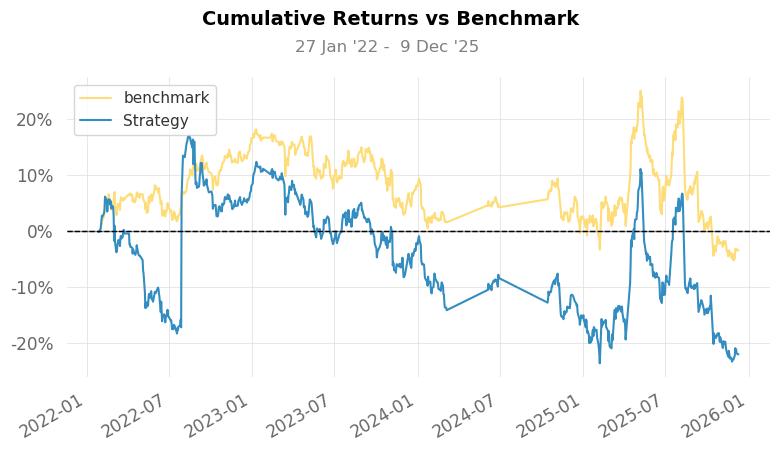

2026-07-25 15:05:13,941 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:13,941 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,136 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,137 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,138 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


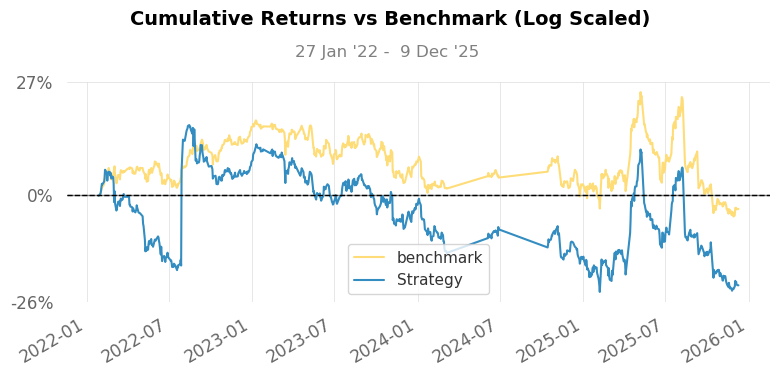

2026-07-25 15:05:14,259 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,260 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,429 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,430 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,432 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


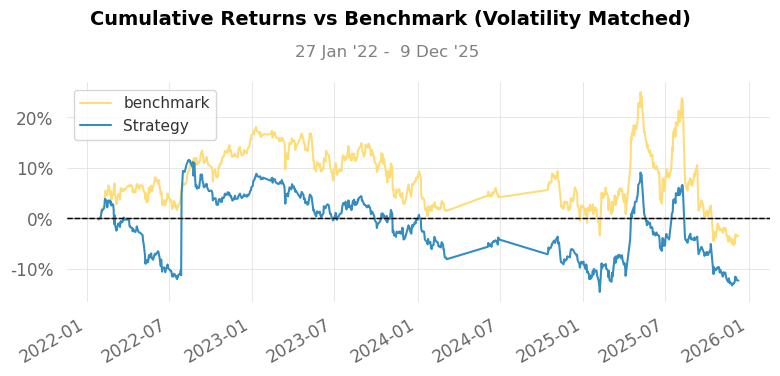

2026-07-25 15:05:14,550 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,551 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,642 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,643 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,644 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


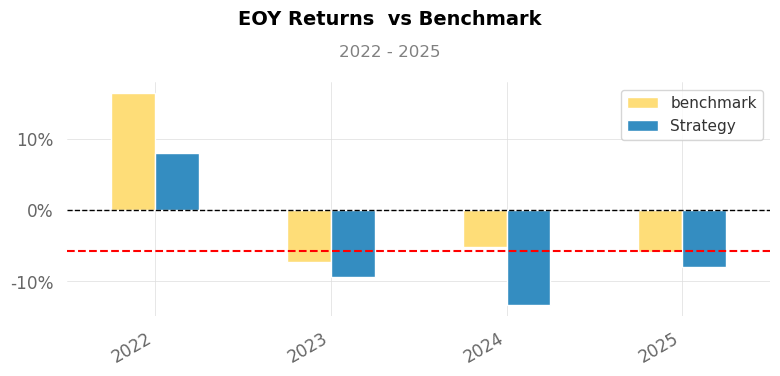

2026-07-25 15:05:14,834 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,835 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,972 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,973 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:14,974 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


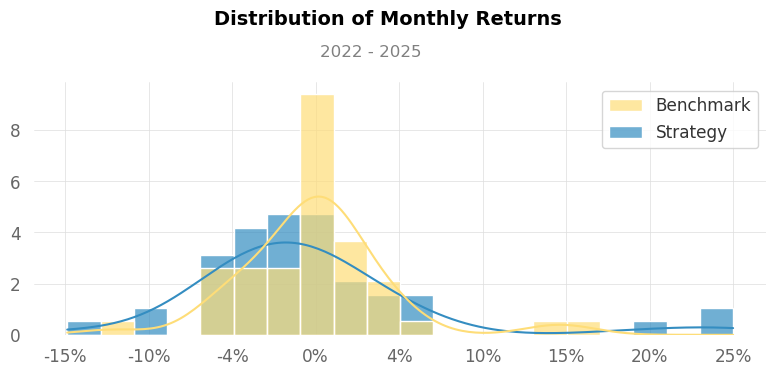

2026-07-25 15:05:15,080 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,081 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,231 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,232 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,234 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


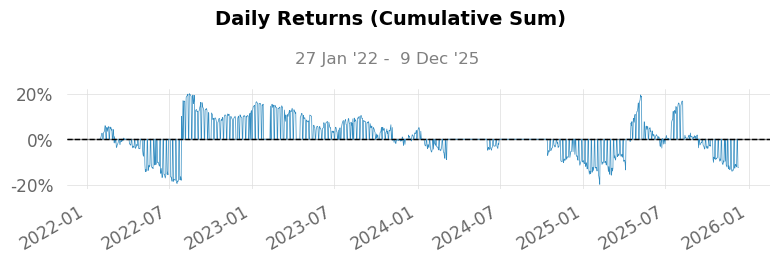

2026-07-25 15:05:15,378 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,379 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,584 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,585 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,586 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


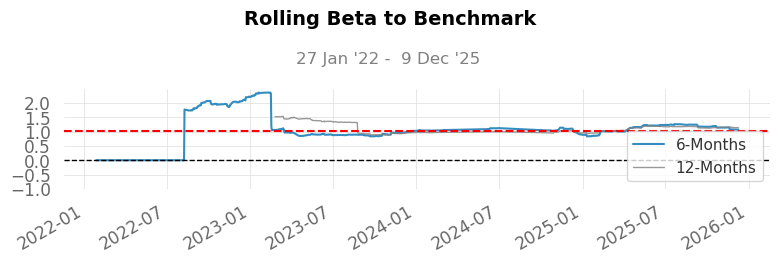

2026-07-25 15:05:15,711 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,711 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,924 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,925 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:15,927 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


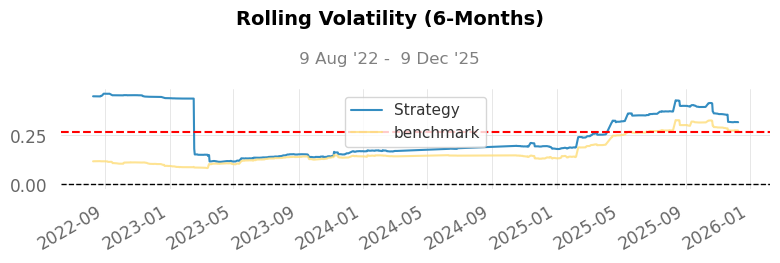

2026-07-25 15:05:16,038 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,039 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,211 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,212 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,213 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


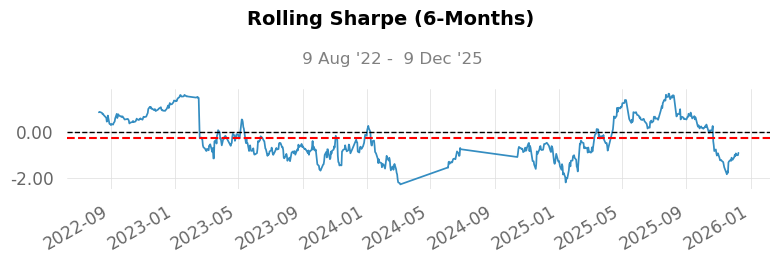

2026-07-25 15:05:16,331 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,332 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,504 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,505 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,506 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


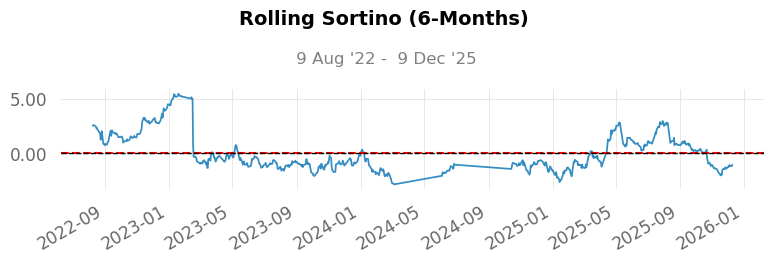

2026-07-25 15:05:16,648 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,649 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,823 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,824 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,825 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


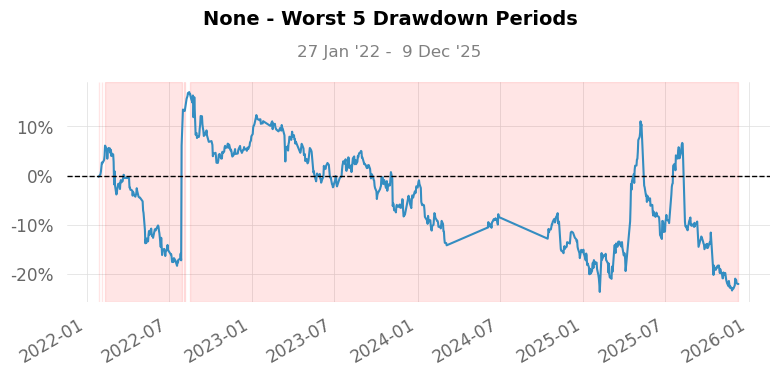

2026-07-25 15:05:16,947 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:16,948 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,104 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,105 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,106 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


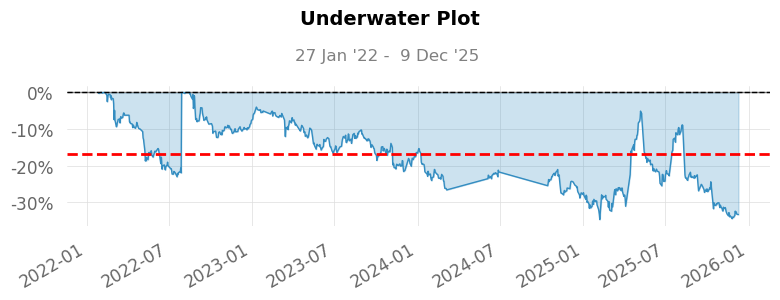

2026-07-25 15:05:17,225 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,226 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,227 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,229 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,479 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,480 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,482 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,483 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


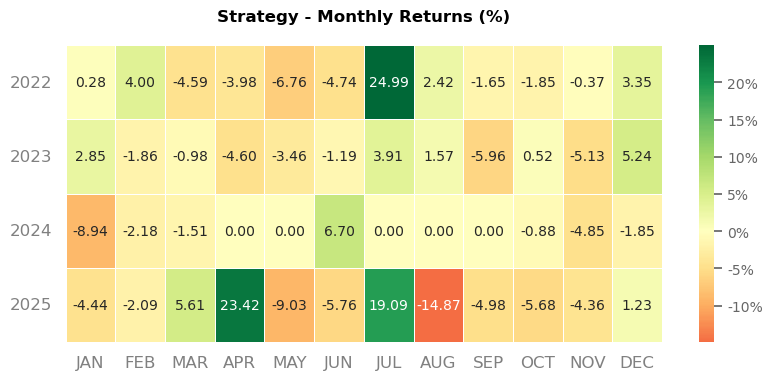

2026-07-25 15:05:17,734 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,735 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,825 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,826 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 15:05:17,827 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


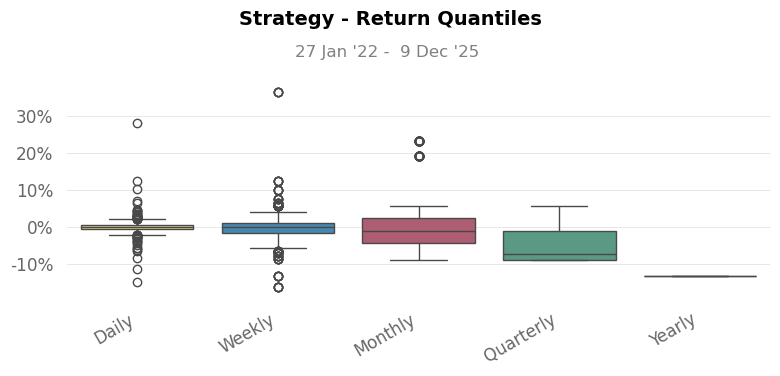

In [55]:
import quantstats as qs

# ดึง Return Series รายวัน
ret_genai = portfolio.returns()
ret_ew = portfolio_ew.returns()
ret_gbm = portfolio_gbm.returns()

# พล็อต Cumulative Returns เปรียบเทียบทั้ง 3 โมเดล
df_all_returns = pd.DataFrame({
    'Generative AI + MPT': ret_genai,
    'GBM + MPT': ret_gbm,
    'Equal Weight (EW)': ret_ew
})

qs.reports.full(ret_genai, benchmark=ret_ew, rf=RF_RATE)

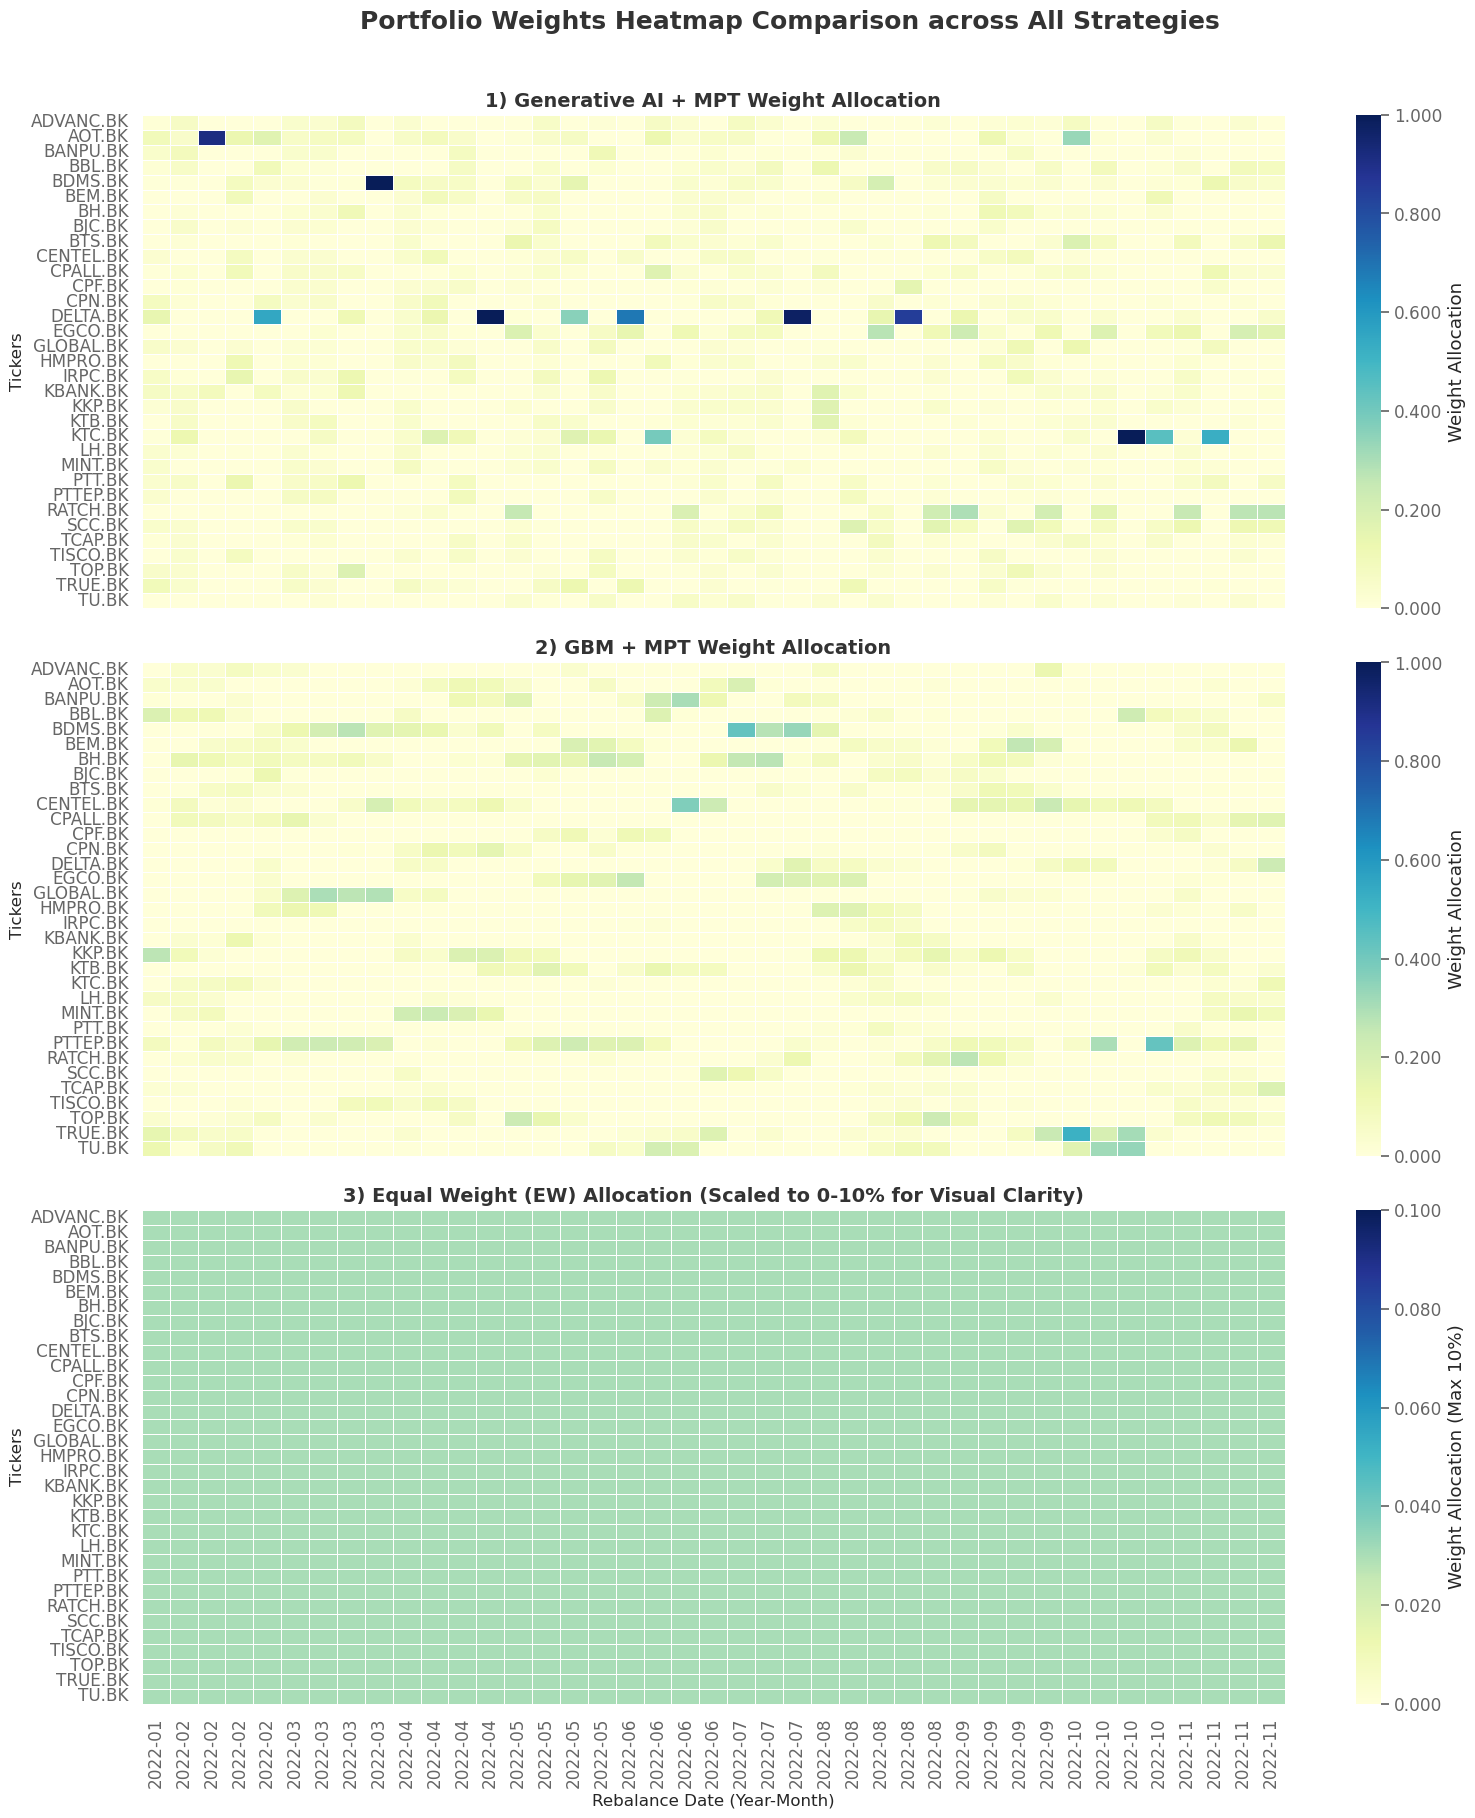

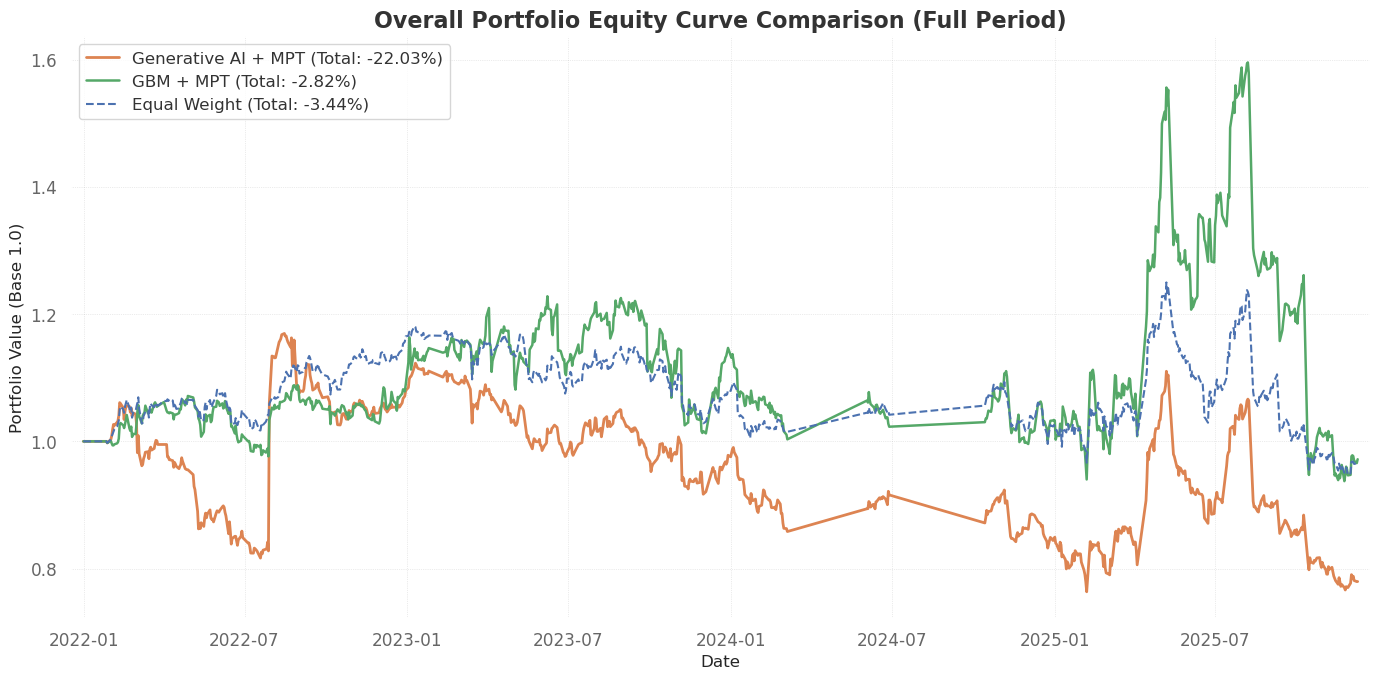

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# พล็อต Heatmap พร้อมปรับแถบสเกลสีให้แสดงทศนิยม 3 ตำแหน่ง
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# เตรียมข้อมูล Transpose และ Format Date
df_hm_model = df_weights.T
df_hm_model.columns = df_hm_model.columns.strftime('%Y-%m')

df_hm_gbm = df_weights_gbm.T
df_hm_gbm.columns = df_hm_gbm.columns.strftime('%Y-%m')

df_hm_ew = df_weights_ew.T
df_hm_ew.columns = df_hm_ew.columns.strftime('%Y-%m')

# 1. Generative AI + MPT
sns.heatmap(
    df_hm_model,
    cmap='YlGnBu',
    linewidths=0.5,
    vmin=0,
    vmax=1.0,
    yticklabels=True, # 🔥 บังคับโชว์แกน Y ทุกตัว
    cbar_kws={'label': 'Weight Allocation', 'format': '%.3f'},
    ax=axes[0],
)
axes[0].set_title('1) Generative AI + MPT Weight Allocation', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tickers', fontsize=12)

# 2. GBM + MPT
sns.heatmap(
    df_hm_gbm,
    cmap='YlGnBu',
    linewidths=0.5,
    vmin=0,
    vmax=1.0,
    yticklabels=True, # 🔥 บังคับโชว์แกน Y ทุกตัว
    cbar_kws={'label': 'Weight Allocation', 'format': '%.3f'},
    ax=axes[1],
)
axes[1].set_title('2) GBM + MPT Weight Allocation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tickers', fontsize=12)

# 3. Equal Weight (EW)
sns.heatmap(
    df_hm_ew,
    cmap='YlGnBu',
    linewidths=0.5,
    vmin=0,
    vmax=0.10,
    yticklabels=True, # 🔥 บังคับโชว์แกน Y ทุกตัว
    cbar_kws={'label': 'Weight Allocation (Max 10%)', 'format': '%.3f'},
    ax=axes[2],
)
axes[2].set_title('3) Equal Weight (EW) Allocation (Scaled to 0-10% for Visual Clarity)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rebalance Date (Year-Month)', fontsize=12)
axes[2].set_ylabel('Tickers', fontsize=12)

# หมุนชื่อแกน Y ให้เป็นแนวนอนอ่านง่ายๆ
for ax in axes:
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Portfolio Weights Heatmap Comparison across All Strategies', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# ==========================================
# 2. พล็อตกราฟ Overall Portfolio Equity Curve ทั้ง 3 กลยุทธ์
# ==========================================
# ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0
eq_model = portfolio.value() / portfolio.value().iloc[0]
eq_gbm = portfolio_gbm.value() / portfolio_gbm.value().iloc[0]
eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]

# คำนวณผลตอบแทนรวม (Total Return %)
tot_ret_model = (eq_model.iloc[-1] - 1) * 100
tot_ret_gbm = (eq_gbm.iloc[-1] - 1) * 100
tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100

plt.figure(figsize=(14, 7))

# พล็อตเส้นกราฟทั้ง 3 โมเดล
plt.plot(
    eq_model.index,
    eq_model,
    label=f'Generative AI + MPT (Total: {tot_ret_model:.2f}%)',
    color='#dd8452',
    linewidth=2.0,
)
plt.plot(
    eq_gbm.index,
    eq_gbm,
    label=f'GBM + MPT (Total: {tot_ret_gbm:.2f}%)',
    color='#55a868',
    linewidth=1.8,
)
plt.plot(
    eq_ew.index,
    eq_ew,
    label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)',
    color='#4c72b0',
    linewidth=1.5,
    linestyle='--',
)

plt.title(
    'Overall Portfolio Equity Curve Comparison (Full Period)',
    fontweight='bold',
    fontsize=16,
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.grid(True, alpha=0.3, color='gray', linestyle=':')
plt.margins(x=0.01)
plt.tight_layout()
plt.show()